

- Recommendation Systems Introduction
- Content Based Filtering


## Introduction

Recommendation engines are everywhere these days. In fact, some of the biggest brands we engage with every day are built around one, including Netflix, Amazon, Google, and Goodreads. 35 % of purchases on Amazon come from product recommendations. 

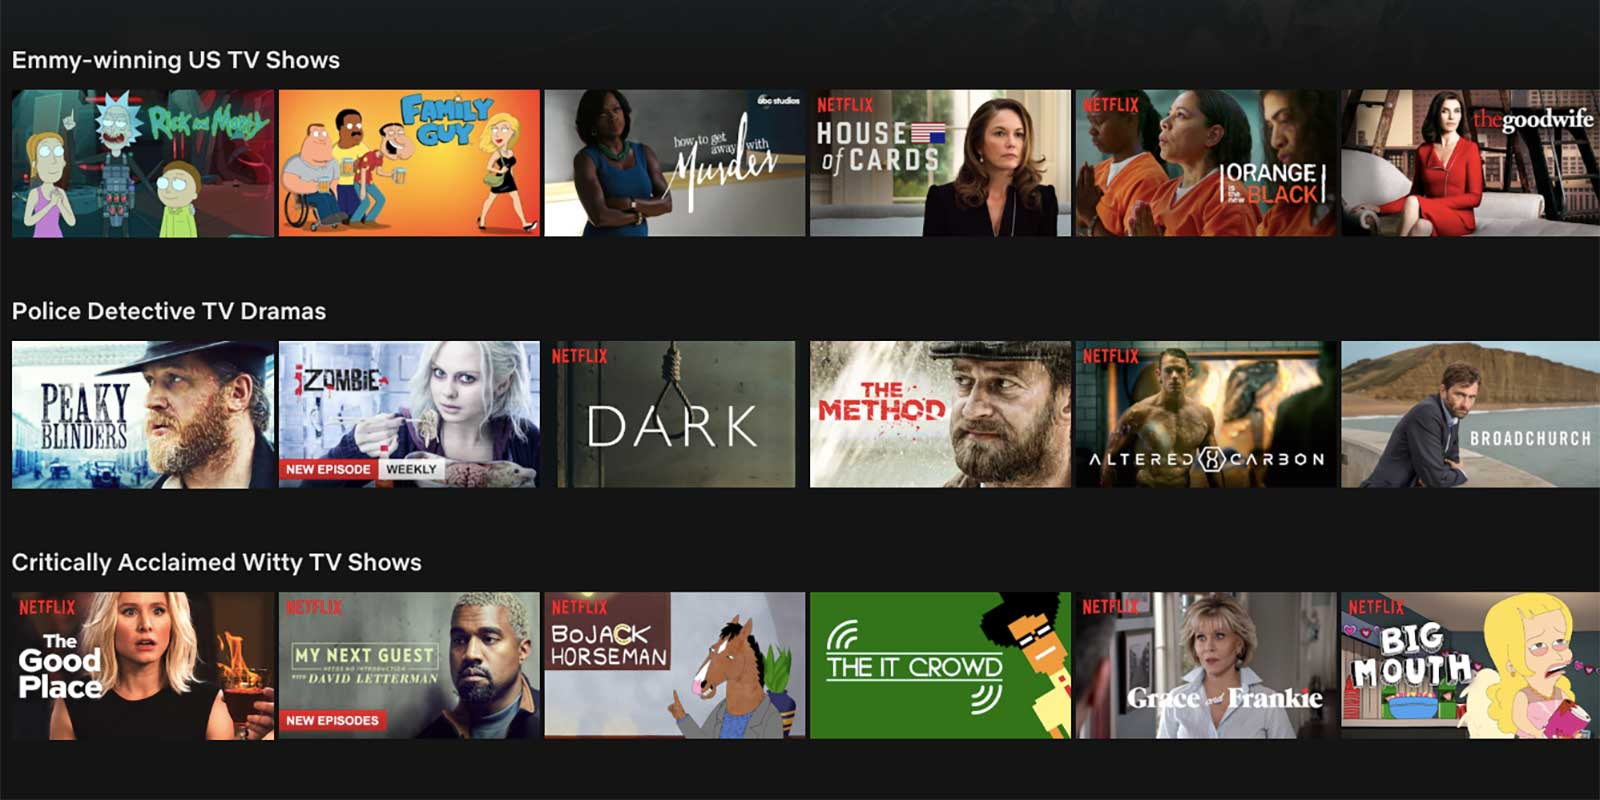

Recommendation Engines Leverage User Data

Recommender systems are often seen as a “black box”; the models created by these large companies are not very easily interpretable. Often, the recommendations surface products or content users didn’t realize they needed or wanted —- until they were presented with them.

* Recommendation Systems belong to the domains of Information Retrieval, Data Mining and Machine Learning.
* Recommender systems play a major role in today's ecommerce industry. Their primary use is to recommend products and content to users. 
* Recommender systems provide users with personalized recommendations based on prior user input and behavior
* Recommends help e-commerce vendors to maximize sales, improve and personalize users' experience, and retain customers. 
* They address the "information overload" problem. 
* The methodology used by recommender systems has evolved over time (Vaidya et al., 2017 https://ieeexplore.ieee.org/abstract/document/8390037.  Dong et al., 20202 https://arxiv.org/pdf/2209.01860)

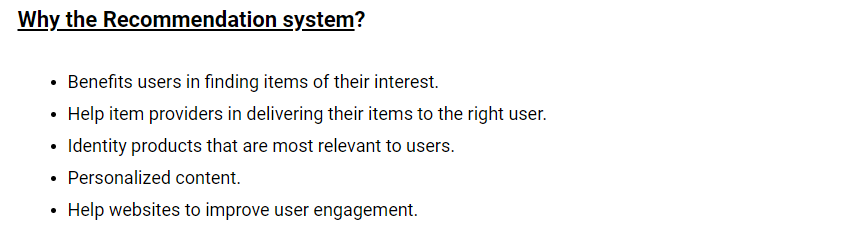

### To efficiently deal with the information overload in the era of big data

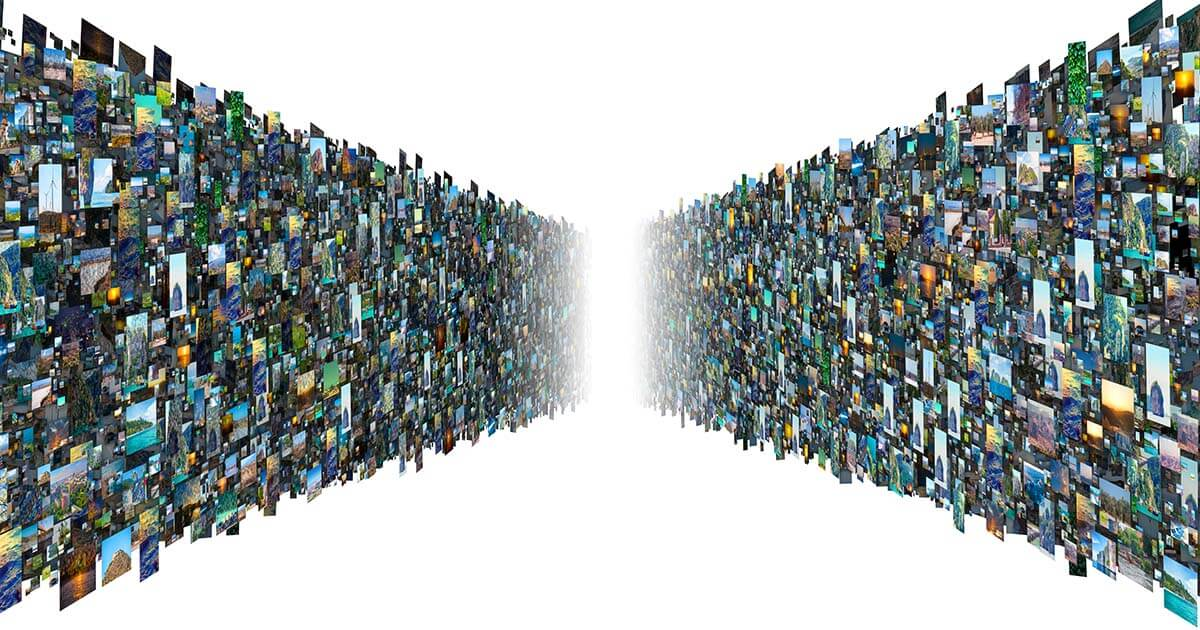

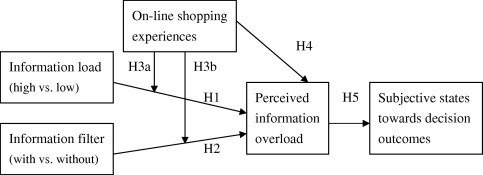(Chen et al., 2009)

1. What items did the customer buy?
2. What are they browsing?
3. What did they click on?
4. What are the star ratings?

## Types of Recommendation Systems ##  

### Content-based Filtering ("CBF") ###

CBF works on the principle that if a user likes a particular item, (s)he will also like other items with similar characteristics. To generate recommendations, algorithms build a profile of the user’s preferences and a description of an item (genre, product type, color, word length). Similarity between items is typically calculated using distance metrics like cosine similarity or Euclidean distance.  

The downside of CBF is that the system is limited to recommending products or content similar to what the person is already buying or using. It can’t go beyond this to recommend other types of products or content. For example, if a customer had only watched detective shows in the past, its predictions will be limited to other detective shows

The earliest models used CBF

### Collaborative Filtering ("CF") ###

CF focuses on collecting and analyzing data on user behavior, activities, and preferences, to predict what a person will like, based on their similarity to other users. To plot and calculate these similarities, CF uses matrix analysis. 

Collaborative filtering doesn’t need to analyze or understand the content (products, films, books). It simply picks items to recommend based on what we know about the user, reflecting the behavior and preferences of neighbors. 

There are two general approaches for identifying neighbors
- k Nearest Neighbors algorithm. 
- Latent Factor Models (LFM). LFMs projects users and items into a joint latent factor space, then decompose the matrix.

As we will see, there a few variations on each approach

CF rose to prominence after winning the Netflix Prize in 2009

### Hybrid Models ###

* Hybrid models combine elements of CF and CBF. Natural Language Processing is used to generate product embeddings from descriptions and metadata which are combined with user embeddings. Matrix Factorization and other approaches to reduce the dimensionality which reflect both the interests of similar users and similarity of products. 

Netflix uses a hybrid approach.  




### Deep Learning in Recommendation Engines

In recent years, Deep Learning has powered advances in recommendation engines:

- Users are sometimes represented as nodes in a graph. Graph Neural Networks then infer connections between users and use convolutional layers to aggregate preferences across neighborhoods of users
- Transformer layers perform some of the dimensionality reduction previously handled by Matrix Factorization
- Nonlinear models can sometimes better express user tastes
- Cross-domain apporaches can cover music, movies, and television shows in a single model



https://itnext.io/what-are-the-top-recommendation-engine-algorithms-used-nowadays-646f588ce639

In Part I of lab, we will practice CBF, starting with a small Model

## Training Content-based Filtering (CBF)

Our data for this model comes from MovieLens https://grouplens.org/datasets/movielens/

GroupLens publishes several movie review datassets for research, the smallest includes ratings by 100,000 users of 9000 movies.

This model we will utilize only the movie table. (In Part II, we will return to this dataset.)

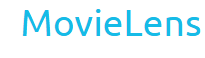

In [1]:
# Download the actual data from

from tensorflow import keras
from zipfile import ZipFile
from pathlib import Path
import pandas as pd

movielens_data_file_url = (
    "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
)
movielens_zipped_file = keras.utils.get_file(
    "ml-latest-small.zip", movielens_data_file_url, extract=False
)
keras_datasets_path = Path(movielens_zipped_file).parents[0]
movielens_dir = keras_datasets_path / "ml-latest-small"
# Only extract the data the first time the script is run.
if not movielens_dir.exists():
    with ZipFile(movielens_zipped_file, "r") as zip:
        # Extract files
        print("Extracting all the files now...")
        zip.extractall(path=keras_datasets_path)
        print("Done!")
        
movie_file = movielens_dir / "movies.csv"
size = 1000 
df_movies = pd.read_csv(movie_file)

Our methodology is to develop a set of features for each movie, then determine the cosine similarity for features of each movie pair. If there are n features, the normalized dot product of feature matrices is the cosine. Movies where all features agree will have a value of 1, those which are independent have a value of 0.  In the example below, we rescale results to a [0,100] scale

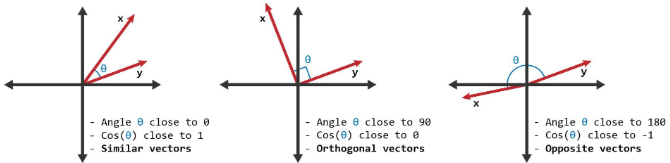

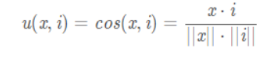

In this example, our featurization is based on word counts in the title. Our simplistic assumption is that similar wording in titles implies similar content. Our TFIDF relies on exact word matches, there is no allowance for semantic similarity or even stemming.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer as TfV
import tensorflow as tf 

import numpy as np

def get_subset(df, number):
    """
    just get a subset of a large dataset for debug purpose
    """
    rids = np.arange(df.shape[0])
    np.random.seed(42)
    np.random.shuffle(rids)
    return df.iloc[rids[:number], :].copy()


df_movies_short = get_subset(df_movies, size).reset_index(drop=True)

# compute TFIDF on the titles of the movies
tfx = TfV(analyzer='word', ngram_range=(1, 3), min_df=1, stop_words='english')
tfidf_matrix = tfx.fit_transform(df_movies_short['title'])


In [3]:
# build a dictionary with the results, allow several minutes
from tqdm.notebook import tqdm
from sklearn.metrics.pairwise import linear_kernel

cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)
results = {}
for idx, row in tqdm(df_movies_short.iterrows(), total=len(df_movies_short)):
    similar_indices = cosine_similarities[idx].argsort()[:-size:-1]
    similar_items = [( round(cosine_similarities[idx][i]*100., 2), 
                      df_movies_short['movieId'].loc[[i]].tolist()[0])
                     for i in similar_indices]
    results[idx] = similar_items[1:]

  0%|          | 0/1000 [00:00<?, ?it/s]

The preceding cell derived  cosine similarities between all pairs. This approach has training time  O(m n²) where n is the number of records and m is the number of features. 

Our TFIDF has a vocabulary of 5437, not a very efficient taxonomy. Iterating in pandas is slow. Because we limited our example to n=1000 movies, it completed in a few minutes. If we utilized all 9000+ movies in the small extract, the algo would have required hours. With the large dataset, several days would be needed

There are more efficient methods, as discussed below.

However, once the cosine similarity matrix is computed, inference (generating recommendations) is extremely fast

In [4]:
def recommended_items(movie_id, num):
    """
    movie_id: the id of the movie
    num: number of recommended items to return
    returns: a list of (score, movie_id) tuples
    """
    # first find the movie_id in df_movies_short
    print("Recommendations for", df_movies.query(f'movieId=={movie_id}').title.values[0])
    
    idx = df_movies_short.index[df_movies_short['movieId'] == movie_id].tolist()
    if len(idx) == 0:
        print('movie id not found')
        return []
    idx = idx[0]
    # now get the top similar items
    scores = pd.DataFrame(results[idx][:num],columns=['score', 'movieId']).merge(df_movies, left_on='movieId', right_on='movieId').query('score>0.0' )[[ 'title', 'movieId',  'score']]
    styled_scores = scores.style.format({"score": "{:.1f}"}).background_gradient(subset=["score"], cmap="Blues")
    return styled_scores

example_movie = df_movies_short.head(2).movieId.values[0] 
recommended_items(example_movie, 10)

Recommendations for Notorious Bettie Page, The (2005)


,title,movieId,score
0,C.R.A.Z.Y. (2005),40870,21.7
1,Notorious (2009),65810,20.5
2,Game 6 (2005),45648,9.4
3,"Baxter, The (2005)",36477,8.8
4,Syriana (2005),40583,8.8
5,Hostel (2005),42723,8.8
6,King Kong (2005),41569,6.2
7,Saw II (2005),39446,6.1
8,Hard Candy (2005),44974,5.9
9,Happy Endings (2005),34164,5.9


This recommender rates the movie with Notorious in its title high. Also (2005) is treated a word, and all movies with "(2005)" in the title get high scores

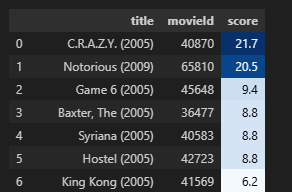

 A realistic CBF recommender would look at a wider range of features including genre, director, actors, keywords, etc.    

To get suitable data, let's try another dataset
 https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

### Data Loading and Cleaning: TMBD

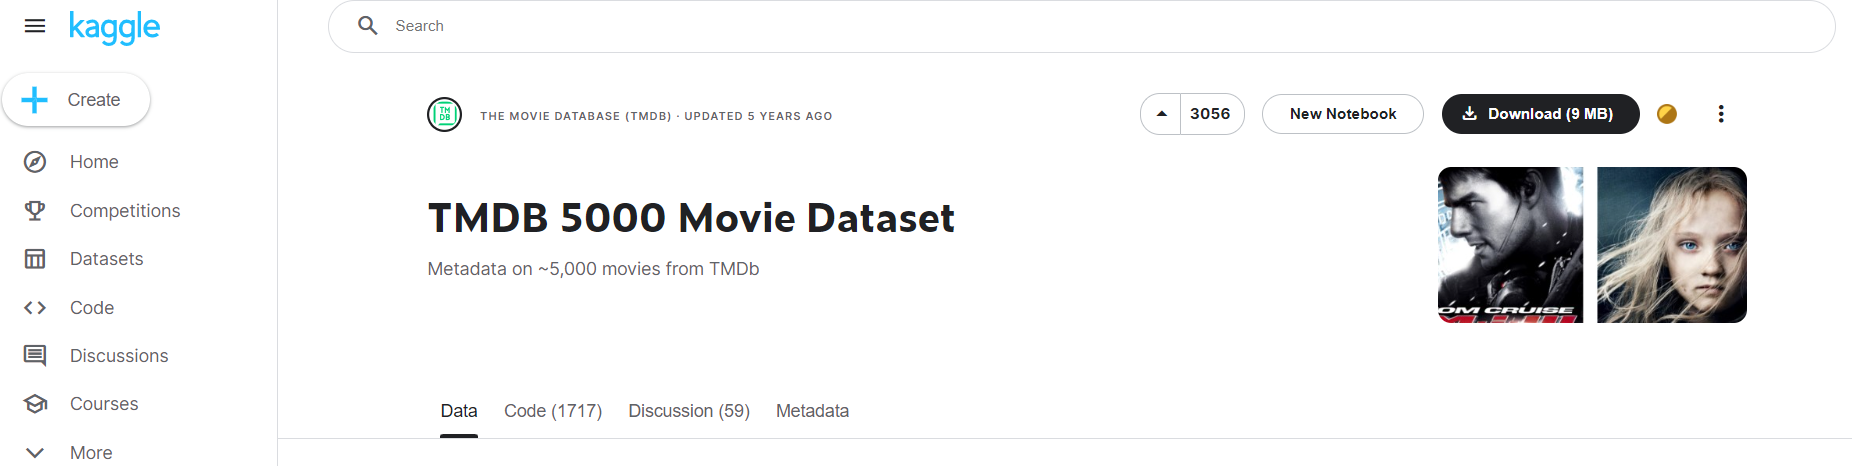

### Feature Extraction: TMDB

https://www.kaggle.com/code/elahehgolrokh/tmdb-movie-data-cleaning-and-eda 

https://medium.com/web-mining-is688-spring-2021/film-recommendation-system-using-content-based-filtering-eb856c7359f3

In [5]:
import json
import kagglehub
#conda has version 0.3.8 which works but generates a warning

def load_tmdb_movies(path):
    df = pd.read_csv(path)
    df['release_date'] = pd.to_datetime(df['release_date']).apply(lambda x: x.date())
    json_columns = ['genres', 'keywords', 'production_countries', 'production_companies', 'spoken_languages']
    for column in json_columns:
        df[column] = df[column].apply(json.loads)
    return df

def load_tmdb_credits(path):
    df = pd.read_csv(path)
    json_columns = ['cast', 'crew']
    for column in json_columns:
        df[column] = df[column].apply(json.loads)
    return df

path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
pd.options.display.max_columns = 50
credits = load_tmdb_credits(path + '/tmdb_5000_credits.csv') 
movies = load_tmdb_movies(path + '/tmdb_5000_movies.csv') 
df = pd.merge(movies, credits, left_on='id', right_on='movie_id')
print(df.shape)
df.head(2).T


(4803, 24)


,0,1
budget,237000000,300000000
genres,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
homepage,http://www.avatarmovie.com/,http://disney.go.com/disneypictures/pirates/
id,19995,285
keywords,"[{'id': 1463, 'name': 'culture clash'}, {'id':...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na..."
original_language,en,en
original_title,Avatar,Pirates of the Caribbean: At World's End
overview,"In the 22nd century, a paraplegic Marine is di...","Captain Barbossa, long believed to be dead, ha..."
popularity,150.437577,139.082615
production_companies,"[{'name': 'Ingenious Film Partners', 'id': 289...","[{'name': 'Walt Disney Pictures', 'id': 2}, {'..."


In [6]:
# Source: https://www.kaggle.com/code/elahehgolrokh/tmdb-movie-data-cleaning-and-eda 
# Columns that existed in the IMDB version of the dataset and are gone.
LOST_COLUMNS = [
    'actor_1_facebook_likes',
    'actor_2_facebook_likes',
    'actor_3_facebook_likes',
    'aspect_ratio',
    'cast_total_facebook_likes',
    'color',
    'content_rating',
    'director_facebook_likes',
    'facenumber_in_poster',
    'movie_facebook_likes',
    'movie_imdb_link',
    'num_critic_for_reviews',
    'num_user_for_reviews']
#____________________________________
# Columns in TMDb that had direct equivalents in the IMDB version.
# These columns can be used with old kernels just by changing the names
TMDB_TO_IMDB_SIMPLE_EQUIVALENCIES = {
    'budget': 'budget',
    'genres': 'genres',
    'revenue': 'gross',
    'title': 'movie_title',
    'runtime': 'duration',
    'original_language': 'language',
    'keywords': 'plot_keywords',
    'vote_count': 'num_voted_users'}
#_____________________________________________________
IMDB_COLUMNS_TO_REMAP = {'imdb_score': 'vote_average'}
#_____________________________________________________
def safe_access(container, index_values):
    """return missing value rather than an error upon indexing/key failure"""
    result = container
    try:
        for idx in index_values:
            result = result[idx]
        return result
    except IndexError or KeyError:
        return np.nan
#_____________________________________________________
def get_director(crew_data):
    directors = [x['name'] for x in crew_data if x['job'] == 'Director']
    return safe_access(directors, [0])
#_____________________________________________________
def pipe_flatten_names(keywords):
    return '|'.join([x['name'] for x in keywords])
#_____________________________________________________
def convert_to_original_format(movies, credits):
    """
    Converts TMDb data to make it as compatible as possible with kernels
    built on the original version of the data
    """
    tmdb_movies = movies.copy()
    tmdb_movies.rename(columns=TMDB_TO_IMDB_SIMPLE_EQUIVALENCIES, inplace=True)
    tmdb_movies['title_year'] = pd.to_datetime(tmdb_movies['release_date']).apply(lambda x: x.year)
    # I'm assuming that the first production country is equivalent, but have not been able to validate this
    tmdb_movies['country'] = tmdb_movies['production_countries'].apply(lambda x: safe_access(x, [0, 'name']))
    tmdb_movies['language'] = tmdb_movies['spoken_languages'].apply(lambda x: safe_access(x, [0, 'name']))
    tmdb_movies['director_name'] = credits['crew'].apply(get_director)
    tmdb_movies['actor_1_name'] = credits['cast'].apply(lambda x: safe_access(x, [1, 'name']))
    tmdb_movies['actor_2_name'] = credits['cast'].apply(lambda x: safe_access(x, [2, 'name']))
    tmdb_movies['actor_3_name'] = credits['cast'].apply(lambda x: safe_access(x, [3, 'name']))
    tmdb_movies['genres'] = tmdb_movies['genres'].apply(pipe_flatten_names)
    tmdb_movies['plot_keywords'] = tmdb_movies['plot_keywords'].apply(pipe_flatten_names)
    tmdb_movies['production_companies'] = tmdb_movies['production_companies'].apply(pipe_flatten_names)
    tmdb_movies['production_countries'] = tmdb_movies['production_countries'].apply(pipe_flatten_names)
    return tmdb_movies

There are 4803 movies. We will filter out roughly half the  movies based on language, vote_average, and # of votes

In [7]:
films_df = convert_to_original_format(movies, credits)
films_df = films_df.query("vote_average >= 6 & num_voted_users >= 4 & language == 'English'").reset_index()
films_df.shape

(2463, 27)

### Feature Extraction: TMBD

We will continue to look for similiarity in content based on  features. But instead of using the words in the title, we will use the following 4 feature groups

- directors (503)
- genres (20)
- actors (1261)
- keywords (1361)


Altogether we need m=3145 features, more compact than our TFIDF approach. We will create a m x n one hot array. array[i,j] will be populated with 1 if film i has feature j and 0 otherwise. We will create four smaller arrays and combine them

### Directors

There are 503 directors who directed at least 2 movies in TMDB.

In [8]:
import warnings
from sklearn.preprocessing import MultiLabelBinarizer

# Get director counts and filter directors with at least 2 movies
dir1 = films_df.director_name.value_counts()
directors = dir1[dir1 > 1].index

# Ensure director_name is a string and handle missing values
films_df['director_name'] = films_df['director_name'].fillna('').astype(str)

# Convert director_name to list for MultiLabelBinarizer
films_df['dir2'] = films_df['director_name'].apply(lambda x: [x] if x else [])

mlb = MultiLabelBinarizer(classes=directors)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    directors_matrix = mlb.fit_transform(films_df['dir2'].tolist())
directors_matrix.shape


(2463, 503)

In [9]:
directors 

Index(['Martin Scorsese', 'Steven Spielberg', 'Clint Eastwood', 'Woody Allen',
       'Spike Lee', 'Tim Burton', 'Ron Howard', 'Ridley Scott', 'Oliver Stone',
       'Richard Donner',
       ...
       'Jamie Babbit', 'Tim Robbins', 'Stephen Hopkins', 'Phyllida Lloyd',
       'Ronald F. Maxwell', 'John Milius', 'Michael Cimino', 'Jon Hurwitz',
       'Ruben Fleischer', 'Alexandre Aja'],
      dtype='object', name='director_name', length=503)

#### Genres

TMDB classified movies into 20 Genres. Some movies transcend their primary genre. 

In [10]:
films_df.genres.value_counts() 

genres
Drama                              245
Drama|Romance                      114
Comedy                              97
Comedy|Drama                        90
Comedy|Drama|Romance                64
                                  ... 
Family|Drama                         1
Science Fiction|Action|Thriller      1
Drama|Romance|Fantasy                1
Action|Adventure|Thriller|Drama      1
Comedy|Drama|Romance|TV Movie        1
Name: count, Length: 745, dtype: int64

In [11]:
genres = list(filter(None, films_df.genres.str.split('|').explode().value_counts().index))
"; ".join(genres)

'Drama; Comedy; Thriller; Action; Romance; Crime; Adventure; Science Fiction; Family; Fantasy; Mystery; Horror; Animation; Music; History; War; Documentary; Western; Foreign; TV Movie'

In [12]:
# Convert genre to list for MultiLabelBinarizer
# handle | as separator
films_df['genres2'] = films_df['genres'].fillna('').apply(lambda x: x.split('|') if x else [])

mlb = MultiLabelBinarizer(classes=genres)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    genres_matrix = mlb.fit_transform(films_df['genres2'].tolist())
# Show the shape of the genres_matrix and a quick check of genre encoding for the first few films
print("Genres matrix shape:", genres_matrix.shape)
print("First 3 films' genres:", films_df['genres'].head(3).tolist())
print("Genres encoded (sum per film):", genres_matrix.sum(axis=1)[:3])

Genres matrix shape: (2463, 20)
First 3 films' genres: ['Action|Adventure|Fantasy|Science Fiction', 'Adventure|Fantasy|Action', 'Action|Crime|Drama|Thriller']
Genres encoded (sum per film): [4 3 4]


### Actors

The dataset lists 3 actors per movie. There are 416 actors who show up in at least 2 movies

In [13]:
actors1 = pd.concat([films_df.actor_1_name , films_df.actor_2_name, films_df.actor_3_name]).value_counts()
actors = actors1[actors1>=2].index

films_df['actors'] = films_df['actor_1_name'].fillna('') +  '|' +\
    films_df['actor_2_name'].fillna('') + '|' + films_df['actor_3_name'].fillna('')
films_df['actors'] = films_df['actors'].str.strip('|')

# Convert actor to list for MultiLabelBinarizer
#handle | as separator
films_df['actorz'] = films_df['actors'].apply(lambda x: x.split('|') if x else [])

mlb = MultiLabelBinarizer(classes=actors)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    actors_matrix = mlb.fit_transform(films_df['actorz'].tolist())

actors_matrix.shape
#actors_matrix = mlb.fit_transform(films_df['actors'])

(2463, 1261)

### Keyword Features

We first list the keywords which are in the dataset:

In [14]:
# Source: https://www.kaggle.com/code/elahehgolrokh/tmdb-movie-data-cleaning-and-eda 
def count_word(df, ref_col, liste):
    keyword_count = dict()
    for s in liste: keyword_count[s] = 0
    for liste_keywords in df[ref_col].str.split('|'):        
        if type(liste_keywords) == float and pd.isnull(liste_keywords): continue        
        for s in [s for s in liste_keywords if s in liste]: 
            if pd.notnull(s): keyword_count[s] += 1
    keyword_occurences = []
    for k,v in keyword_count.items():
        keyword_occurences.append([k,v])
    keyword_occurences.sort(key = lambda x:x[1], reverse = True)
    return keyword_occurences, keyword_count

keywords = set()
for s in films_df['plot_keywords'].values:
  if not pd.isnull(s):
    s = s.split('|')
    keywords = keywords.union(set(s))
keywords.remove('')
print(len(keywords))


keyword_occurences, dum = count_word(films_df, 'plot_keywords', keywords)
keyword_occurences[:5]

7394


[['independent film', 194],
 ['woman director', 163],
 ['duringcreditsstinger', 160],
 ['based on novel', 139],
 ['murder', 108]]

Browsing through the entire list of keyword_occurrences is instructive. Further down the list you will find entries ike battlefield, cheerleader, snowstorm, and hostage_taking. 

In [15]:
keywordz2 =  [x[0] for x in keyword_occurences if x[1] >= 4 ]
#we could optionally clean up the keywords a bit
#keywordz2 = list(set([x.replace('\xa0','') for x in keywordz2]))
keywordz2.sort()
len(keywordz2)

1361

In [16]:
# Convert plot_keywords to list for MultiLabelBinarizer
#handle | as separator
films_df['plot_keywordsz'] = films_df['plot_keywords'].fillna('').apply(lambda x: x.split('|') if x else [])

mlb = MultiLabelBinarizer(classes=keywordz2)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    keywords_matrix = mlb.fit_transform(films_df['plot_keywordsz'].tolist())

keywords_matrix.shape

(2463, 1361)

## Compile a Feature Matrix

we concatenate the four feature matrices horizontally


In [17]:
feature_matrix = np.hstack([directors_matrix,   genres_matrix, actors_matrix, keywords_matrix])
feature_matrix.shape

(2463, 3145)

### Step One: Given a film, identify k=25 similar films

Once again, we use cosine similarity. But instead of building the entire cosine similarity matrix, we search for just the top k.

Using this approach speeds things up

Note that we need to normalize the combined matrix; in the previous example this was done by default

In [18]:
k=25

from sklearn.preprocessing import normalize
feature_matrix_norm = normalize(feature_matrix)

cosine_similarities = linear_kernel(feature_matrix_norm, feature_matrix_norm)
results = {}
for idx, row in tqdm(enumerate(feature_matrix_norm), total=len(feature_matrix_norm)) :
    size = feature_matrix_norm.shape[0]
    #the s indices with highest similarity, excluding itself
    similar_indices = cosine_similarities[idx,:].argsort()[::-1][1:1+k]
    results[idx] = [ ( round(cosine_similarities[idx][i]*100., 2), 
            films_df.loc[i,'id']  ) for i in similar_indices   ]


  0%|          | 0/2463 [00:00<?, ?it/s]

In [19]:
def similar_movies(movie_id):
    """
    movie_id: the id of the movie
    """
    global subs 
    subs = films_df.query(f'id=={movie_id}')
    if len(subs) == 0:
        print('movie id not found')
        return []
  

    display(subs[[ 'movie_title', 'genres',\
            'director_name',  'plot_keywords']])
    idx = subs.index[0]
    
    print(f"Top {k} Nearest for", subs.movie_title.values[0])
    scores = pd.DataFrame(results[0][:k],columns=['similarity', 'id'])\
        .merge(films_df, left_on='id', right_on='id')[[ 'movie_title', 'id',  'similarity','genres',\
            'director_name',  'plot_keywords']]
    styled_scores = scores.style.format({"similarity": "{:.1f}"}).background_gradient(subset=["similarity"], cmap="Blues")
    return scores 

example_movie = films_df.head(1).id.values[0] 
scores = similar_movies(example_movie)

styled_scores = scores.style.format({"similarity": "{:.1f}"}).background_gradient(subset=["similarity"], cmap="Blues")
styled_scores


,movie_title,genres,director_name,plot_keywords
0,Avatar,Action|Adventure|Fantasy|Science Fiction,James Cameron,culture clash|future|space war|space colony|so...


Top 25 Nearest for Avatar


,movie_title,id,similarity,genres,director_name,plot_keywords
0,Star Trek Into Darkness,54138,43.6,Action|Adventure|Science Fiction,J.J. Abrams,spacecraft|friendship|sequel|futuristic|space|alien|imax|space opera|terrorist bombing|3d
1,Stargate: The Ark of Truth,13001,35.6,Adventure|Science Fiction,Robert C. Cooper,wormhole|space travel|supernatural powers|spaceship|alien
2,Small Soldiers,11551,34.5,Comedy|Adventure|Fantasy|Science Fiction|Action,Joe Dante,defense industry|toy shop|technical toy|soldier|prototype|killer toys|toy comes to life
3,Predator,106,34.5,Science Fiction|Action|Adventure|Thriller,John McTiernan,central and south america|predator|alien|stalking|invisible|commando|3d
4,Aliens,679,33.8,Horror|Action|Thriller|Science Fiction,James Cameron,android|extraterrestrial technology|space marine|spaceman|cryogenics|vacuum|space colony|warrior woman|settler|space travel|colony|alien|xenomorph
5,Predators,34851,32.7,Action|Science Fiction|Adventure|Thriller,Nimród Antal,hunter|predator|yakuza|hunting human beings|alien life-form|sequel|alien|alien planet|jungle|soldier|warrior
6,John Carter,49529,32.7,Action|Adventure|Science Fiction,Andrew Stanton,based on novel|mars|medallion|space travel|princess|alien|steampunk|martian|escape|edgar rice burroughs|alien race|superhuman strength|mars civilization|sword and planet|19th century|3d
7,Cotton Comes to Harlem,59917,30.9,Action|Adventure,Ossie Davis,blaxploitation
8,The Fifth Element,18,30.0,Adventure|Fantasy|Action|Thriller|Science Fiction,Luc Besson,clone|taxi|cyborg|egypt|future|stowaway|space travel|race against time|arms dealer|love|alien|priest|end of the world|good vs evil|shootout|police chase|cab driver|new york city|space opera|military|opera singer|resort hotel|ancient astronaut|archeologist|ancient evil|cruise liner
9,Pirates of the Caribbean: On Stranger Tides,1865,29.3,Adventure|Action|Fantasy,Rob Marshall,sea|captain|mutiny|sword|prime minister|sailing|silver|ship|duke|mermaid|pirate|soldier|battle|swashbuckler|aftercreditsstinger|3d


A little research shows that Zoe Saldana performed in both "Star Trek into Darkness" (the #1 recommendation) and Avatar

It turns out *sklearn* actually has a built-in function to find the k nearest neighbors.

In [20]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(metric='cosine', algorithm='auto')
nn.fit(feature_matrix)

idx=0
_, indices = nn.kneighbors(feature_matrix[0].reshape(1, -1), n_neighbors=26)
similarz2 = [films_df.loc[i].id for i in indices[0]][1:]  #exclude itself
set(scores.id.to_list()).symmetric_difference(set(similarz2))


{102899, 137113}

The results of our handcrafted Nearest Neighbors differs from the sci-kit version only in the 25th place, the result of a tie

### Once we determine the N most similar films, we score them

There are many ways the films can be ranked. Here is one example, it chooses 5 of the 25, based on
  
- rating
- the number of votes the entry received
- proximate release year (difference between user selection and target)

The cosine similarity could also be considered

https://medium.com/web-mining-is688-spring-2021/film-recommendation-system-using-content-based-filtering-eb856c7359f3

In [21]:
import scipy.stats as stats

def ranking_metric(id, similarz) :    
    global gamma, rho, each, mean_users, std_users, target
    target = films_df[films_df.id==id]

    candidates = films_df[films_df.id.isin(similarz)]
    mean_users = candidates.num_voted_users.mean()
    std_users = candidates.num_voted_users.std()
    score_list = []
    for row, each in candidates.iterrows():

        #if sequel(title_main, titre): #fix         note = 0
        if pd.notnull(each.release_date):
            gamma = np.power(.8, 
         (abs((pd.to_datetime(each.release_date)- pd.to_datetime(target.release_date)).dt.days)/365))
        else:
            gamma = .6       


        if pd.notnull(each.num_voted_users):
            #rho = 1 for the mean with a ceiling of 2 and floor of 0
            rho = 2 *stats.norm.cdf((each.num_voted_users - mean_users) / std_users)
        else:
            rho = 0
            

        score_list.append(each.vote_average**2 * gamma * rho)
    return np.array(score_list    )

scores['recommend'] = np.round(ranking_metric(example_movie, scores.id.to_list()),2)
scores2 = scores.sort_values(by='recommend', ascending=False).head(5)[['movie_title',  'recommend']]
styled_scores = scores2.style.format({"recommend": "{:.2f}"}).background_gradient(subset=["recommend"], cmap="Greens")
styled_scores


,movie_title,recommend
1,Stargate: The Ark of Truth,48.69
5,Predators,44.25
4,Aliens,39.70
2,Small Soldiers,38.60
8,The Fifth Element,31.15


### Some Observations

Semantic

Some of these keywords are semantically related. In the example above, keywords like spacecraft, spaceship, space station, space travel, space colony, space marine, and space would be better handled by semantic embedding.

Similarly, a model which can perceive statistical similarities in user ratings of different directors would make this model more powerful

Many blockbusters have sequels that share the same director, actors and keywords.  The recommendation engine will tend to recommend sequels which might be viewed as an undesirable property. Depending on the designer's objectives it may be useful to recommend sequels (but only in the correct sequence) or to filter them out



Our feature matrix is *sparse*; just 0.3% of cells are populated. As we scale up the model, this will become a bigger issue. If our goal is to interpolate users' interests from a very small percentage they sampled, the sparse representation is a hindrance. 

In [22]:
feature_matrix.sum()/feature_matrix.size

0.0033747152612238233

###  Business Model Influences Recommendation Strategy

Subscription platforms (e.g., Netflix, Spotify) often prioritize *precision*. Every irrelevant recommendation risks undermining perceived value, which can increase churn. Trust matters more than quantity; users expect highly accurate, on-brand suggestions.

Ad-supported platforms (e.g. YouTube, BuzzFeed) typically lean toward *recall*. The goal is to keep users engaged as long as possible, even if that means showing a broader mix of content. A few false positives are acceptable if the result is more impressions and session time.

Marketplaces (e.g. Amazon, Etsy) strike a balance. During the checkout journey, high precision is essential for conversion. But in discovery phases, like browsing categories or search, they may favor recall to help users explore a wider range of items.

Source: https://www.shaped.ai/blog/relevancy-precision-and-recall#:~:text=Precision%20and%20recall%20shape%20how,single%20metric%20can%20be%20misleading.

In the example above, lower values of k are associated with higher precision